# **SVM Modeling with PCA**

### **Import Libraries**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

### **Load PCA Processed Data**

In [2]:
X_train_pca = np.load(
    '../data/processed/X_train_pca.npy'
)

X_test_pca = np.load(
    '../data/processed/X_test_pca.npy'
)

y_train = np.load(
    '../data/processed/y_train.npy'
)

y_test = np.load(
    '../data/processed/y_test.npy'
)

## **PCA SVM Modeling**

### **Initialize PCA SVM**

In [3]:
pca_svm = SVC(
    kernel='rbf',
    random_state=42
)

### **Train PCA SVM**

In [5]:
pca_svm.fit(
    X_train_pca,
    y_train
)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### **Prediction**

In [6]:
y_pred_pca = pca_svm.predict(
    X_test_pca
)

## **Evaluation**

### **Accuracy Score**

In [7]:
pca_accuracy = accuracy_score(
    y_test,
    y_pred_pca
)

print(
    f'PCA SVM Accuracy: '
    f'{pca_accuracy:.4f}'
)

PCA SVM Accuracy: 0.8013


### **Classification Report**

In [8]:
print(
    classification_report(
        y_test,
        y_pred_pca
    )
)

              precision    recall  f1-score   support

           0       0.81      0.97      0.88      4673
           1       0.66      0.21      0.32      1327

    accuracy                           0.80      6000
   macro avg       0.73      0.59      0.60      6000
weighted avg       0.78      0.80      0.76      6000



### **Confusion Matrix**

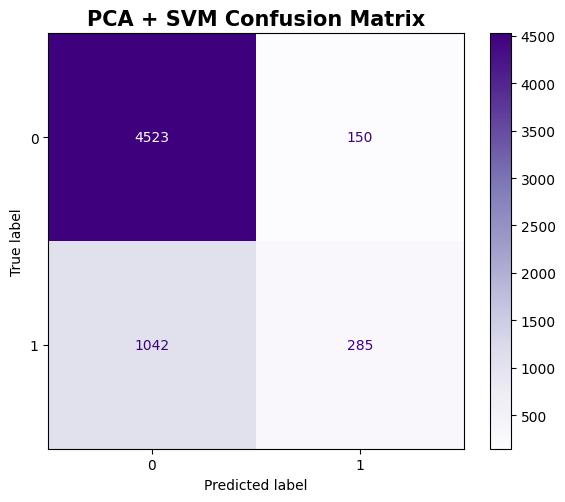

In [9]:
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_pca,
    cmap='Purples',
    ax=ax
)

plt.title(
    'PCA + SVM Confusion Matrix',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

### **ROC-AUC Score**

In [10]:
pca_auc = roc_auc_score(
    y_test,
    y_pred_pca
)

print(
    f'PCA ROC-AUC Score: '
    f'{pca_auc:.4f}'
)

PCA ROC-AUC Score: 0.5913


## **Save PCA Model**

In [11]:
import joblib

joblib.dump(
    pca_svm,
    '../artifacts/svm_pca.pkl'
)

['../artifacts/svm_pca.pkl']